In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V
from aspect_cobalt import *

In [4]:
try:
    batch_count = 103
    genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'rock', 'country', 'pop', 'rap', 'rb', 'misc'}
103


In [5]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50
except:
    traceback.print_exc()

In [6]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [7]:
try:
    cobalt = Cobalt(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Cobalt._prepare_language_model.cached


In [8]:
try:
    # print(cobalt.ds_data.head())
    cobalt._prepare_training_data()
except:
    traceback.print_exc()

In [9]:
try:
    train_language_model = True
    print(cobalt.language_model)
except:
    traceback.print_exc()

BiGRULyricsModel(vocab=16000, embed=512, hidden=512, layers=2, params=8,419,456)


In [ ]:
try:
    train_language_model = True
    print(cobalt.language_model)
except:
    traceback.print_exc()

In [9]:
try:
    if train_language_model:

        cobalt.language_model.trainer.device = 'cuda'

        for pg in cobalt.language_model.trainer.optimizer.param_groups:
            # pg['lr'] = 0.0001
            print(pg['lr'])

        # cobalt.language_model.embedding.weight.requires_grad = True
        print(cobalt.language_model.embedding.weight.requires_grad)

except:
    traceback.print_exc()

0.0001
True


In [10]:
try:
    if train_language_model:
        red.language_model.train_model()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 2.37    TTS: 1.24    ETA: 48318.12
Epoch:  0/ 1    Train Loss: 2.48    TTS: 2.03    ETA: 3767.95
Epoch:  0/ 1    Train Loss: 2.69    TTS: 3.02    ETA: 2455.54
Epoch:  0/ 1    Train Loss: 2.48    TTS: 4.04    ETA: 2097.98
Epoch:  0/ 1    Train Loss: 2.91    Agg. Loss: 2.54    TTS: 5.01    ETA: 1931.28
Epoch:  0/ 1    Train Loss: 1.88    Agg. Loss: 2.50    TTS: 6.02    ETA: 1831.50


Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_24532\2456067357.py", line 3, in <module>
    red.language_model.train_model()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_red\encoder_decoder.py", line 64, in train_model
    self.trainer.train()
    ~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 188, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 233, in _train_step
    self.optimizer.step()
    ~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\optim\optimizer.py", line 533, in wrapper
    out = func(*args, **kwargs)
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\optim\optimizer.py", line 81, in _use_grad
    ret = func(*a

In [11]:
try:
    if train_language_model:
        timers = red.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 0.0
train_dataloader 0.00958039138237045
batch 0.029445591928141644


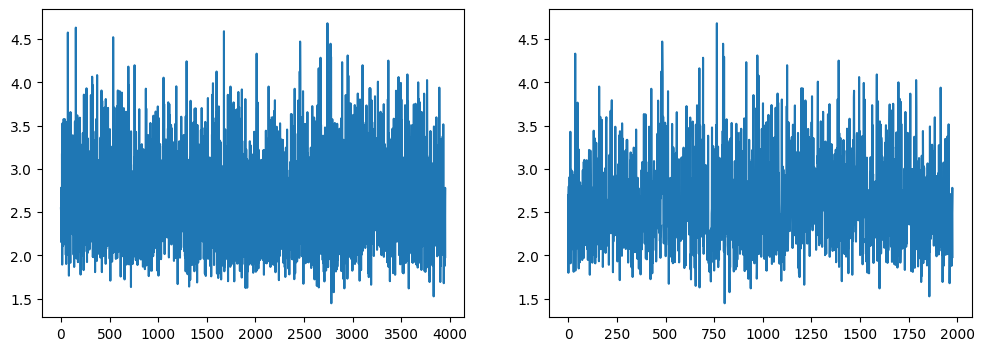

In [12]:
try:
    if train_language_model:
        loss = red.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [13]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Red._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: red.language_model, group='Red._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [14]:
try:
    print(red.inference('rock', ['black', 'enter', 'spell', 'priests', 'dragon'], starting_words='', max_len=400).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

<SONG_START>
<CHORUS>
i had to help it down in my ownest
he know i get a new , my hand in an new
<HOOK>
" who to get with the sun
for a new friends , i've in the bestest room
we only get caught from the wall
it was a new other thing in the one also i'm
i " m a reason to get a
to this shit if i turn up from one of my eyes , a hundredly . 's at the floor , i was my name <SONG_END>
